In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
import selfies as sf
import os, sys
import matplotlib
import matplotlib.pyplot as plt

sys.path.append('../')
sys.path.append('../../')
from fingerprint_analysis.calc_fps_rm import check_smiles_validity
from data_utils_local.data_utils_smiles import plot_smiles_grid

In [2]:
smiles2selfie_fn = lambda x: sf.encoder(x)
canonical_fn = lambda smi: Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=False)
len_filter_fn = lambda x: sf.len_selfies(x)<=128
smiles_clean_fn = lambda x: ('[' not in x) and ('B' not in x.replace('Br', '')) and ('.' not in x)


In [3]:
df = pd.read_csv('/home/rkmvu/Dataset/selfies/drug/mdrug.csv')
_, valid_mask = check_smiles_validity(df['smiles'].tolist())
df = df[valid_mask].copy()
df['smiles'] = df['smiles'].apply(canonical_fn)
df['selfies'] = df['smiles'].apply(smiles2selfie_fn)

len_mask = df['selfies'].apply(len_filter_fn)
df = df[len_mask]

df_temp = df.copy()
mask = df_temp['smiles'].apply(smiles_clean_fn)
df_temp = df_temp[mask]
df_temp = df_temp.drop_duplicates(subset=['smiles'])
smiles_main = df_temp['smiles'].tolist()
smiles_name = df_temp['name'].tolist()
print(f'Number of smiles: {len(smiles_main)}')
df_temp

<===checking smiles validity===>


100%|██████████| 1381/1381 [00:00<00:00, 4922.88it/s]


Number of smiles: 1089


,name,smiles,InChl,type,selfies
0,Abacavir,Nc1nc(NC2CC2)c2ncn(C3C=CC(CO)C3)c2n1,InChI=1S/C14H18N6O/c15-14-18-12(17-9-2-3-9)11-...,Drug,[N][C][=N][C][Branch1][#Branch1][N][C][C][C][R...
1,Abiraterone,CC(=O)OC1CCC2(C)C(=CCC3C2CCC2(C)C(c4cccnc4)=CC...,InChI=1S/C26H33NO2/c1-17(28)29-20-10-12-25(2)1...,Drug,[C][C][=Branch1][C][=O][O][C][C][C][C][Branch1...
2,Acamprosate,CC(=O)NCCCS(=O)(=O)O,"InChI=1S/C5H11NO4S/c1-5(7)6-3-2-4-11(8,9)10/h2...",Drug,[C][C][=Branch1][C][=O][N][C][C][C][S][=Branch...
3,Acarbose,CC1OC(OC2C(CO)OC(OC3C(CO)OC(O)C(O)C3O)C(O)C2O)...,InChI=1S/C25H43NO18/c1-6-11(26-8-2-7(3-27)12(3...,Drug,[C][C][O][C][Branch2][Ring2][#Branch2][O][C][C...
4,Acebutolol,CCCC(=O)Nc1ccc(OCC(O)CNC(C)C)c(C(C)=O)c1,InChI=1S/C18H28N2O4/c1-5-6-18(23)20-14-7-8-17(...,Drug,[C][C][C][C][=Branch1][C][=O][N][C][=C][C][=C]...
...,...,...,...,...,...
1374,Ziprasidone,O=C1Cc2cc(CCN3CCN(c4nsc5ccccc45)CC3)c(Cl)cc2N1,InChI=1S/C21H21ClN4OS/c22-17-13-18-15(12-20(27...,Drug,[O][=C][C][C][=C][C][Branch2][Ring1][#Branch2]...
1375,Zoledronate,O=P(O)(O)C(O)(Cn1ccnc1)P(=O)(O)O,"InChI=1S/C5H10N2O7P2/c8-5(15(9,10)11,16(12,13)...",Drug,[O][=P][Branch1][C][O][Branch1][C][O][C][Branc...
1377,Zolpidem,Cc1ccc(-c2nc3ccc(C)cn3c2CC(=O)N(C)C)cc1,InChI=1S/C19H21N3O/c1-13-5-8-15(9-6-13)19-16(1...,Drug,[C][C][=C][C][=C][Branch2][Ring1][O][C][N][=C]...
1378,Zonisamide,NS(=O)(=O)Cc1noc2ccccc12,"InChI=1S/C8H8N2O3S/c9-14(11,12)5-7-6-3-1-2-4-8...",Drug,[N][S][=Branch1][C][=O][=Branch1][C][=O][C][C]...


In [4]:
canonical_fn = lambda smi: Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=False)
def name2smiles(name):
    row = df_temp[df_temp['name'] == name].iloc[0]
    return row['smiles']

def smiles2name(smiles):
    smiles = canonical_fn(smiles)
    row = df_temp[df_temp['smiles'] == smiles].iloc[0]
    return row['name']

In [5]:
path_init = '/home/rkmvu/Codes/ICDCIT_submission/results/near_smiles_{DATA}.csv'
names_list = ['fp', 'bert', 'evsmi', 'hvsmi', 'evslfi']
names_dict = {'fp':'Morgan_FP', 'bert':'Chemberta2', 'evsmi': 'EVAE (smiles)', 'hvsmi': 'HVAE (smiles)', 'evslfi':'EVAE (selfie)'}

top_drugs = ["Metformin", "Amoxicillin", "Atorvastatin", "Amlodipine", "Acetaminophen", "Imatinib", "Clozapine", 
             "Ibuprofen", "Azithromycin", "Doxycycline"]

all_dfs = []
for name in names_list:
    path_temp = path_init.format(DATA=name)
    temp_df = pd.read_csv(path_temp)
    all_dfs.append(temp_df)

In [6]:
A =(all(all_dfs[0]['drug_fp'] == all_dfs[1]['drug_bert']) &
all(all_dfs[0]['drug_fp'] == all_dfs[2]['drug_evsmi']) &
all(all_dfs[0]['drug_fp'] == all_dfs[3]['drug_hvsmi']) &
all(all_dfs[0]['drug_fp'] == all_dfs[4]['drug_evslfi']))

B =(all(all_dfs[0]['nn_idx_fp'] == all_dfs[1]['nn_idx_bert']) &
all(all_dfs[0]['nn_idx_fp'] == all_dfs[2]['nn_idx_evsmi']) &
all(all_dfs[0]['nn_idx_fp'] == all_dfs[3]['nn_idx_hvsmi']) &
all(all_dfs[0]['nn_idx_fp'] == all_dfs[4]['nn_idx_evslfi']))

A, B

(True, True)

In [7]:
all_results = pd.concat(all_dfs, axis=1)
# all_results.to_csv('/home/rkmvu/Codes/ICDCIT_submission/results/merged_dfs.csv', index=False)
all_results

,drug_fp,nn_idx_fp,smiles_fp,names_fp,drug_bert,nn_idx_bert,smiles_bert,names_bert,drug_evsmi,nn_idx_evsmi,smiles_evsmi,names_evsmi,drug_hvsmi,nn_idx_hvsmi,smiles_hvsmi,names_hvsmi,drug_evslfi,nn_idx_evslfi,smiles_evslfi,names_evslfi
0,Abacavir,1,COc1nc(N)nc2c1ncn2C1OC(CO)C(O)C1O,Nelarabine,Abacavir,1,CN1C2CCCC1CC(NC(=O)c1nn(C)c3ccccc13)C2,Granisetron,Abacavir,1,Nc1nc(Cl)nc2c1ncn2C1CC(O)C(CO)O1,Cladribine,Abacavir,1,CCc1ccc(CCOc2ccc(CC3SC(=O)NC3=O)cc2)nc1,Pioglitazone,Abacavir,1,NC1=NC(Cl)=NC2=C1N=CN2C3OC(CO)C(O)C3F,Clofarabine
1,Abacavir,2,Nc1nc(Cl)nc2c1ncn2C1CC(O)C(CO)O1,Cladribine,Abacavir,2,CN1CCN(C(=O)OC2c3nccnc3C(=O)N2c2ccc(Cl)cn2)CC1,Eszopiclone,Abacavir,2,COc1nc(N)nc2c1ncn2C1OC(CO)C(O)C1O,Nelarabine,Abacavir,2,CC(C)c1ccc2oc3nc(N)c(C(=O)O)cc3c(=O)c2c1,Amlexanox,Abacavir,2,COC1=NC(N)=NC2=C1N=CN2C3OC(CO)C(O)C3O,Nelarabine
2,Abacavir,3,Nc1ncn(C2CC(O)C(CO)O2)c(=O)n1,Decitabine,Abacavir,3,CC(=O)OCC(CCn1cnc2cnc(N)nc21)COC(C)=O,Famciclovir,Abacavir,3,N#CC1CCCN1C(=O)CNC12CC3CC(CC(O)(C3)C1)C2,Vildagliptin,Abacavir,3,Nc1nc(N)c2nc(-c3ccccc3)c(N)nc2n1,Triamterene,Abacavir,3,NC1=NC(Cl)=NC2=C1N=CN2C3CC(O)C(CO)O3,Cladribine
3,Abacavir,4,Nc1nc(Cl)nc2c1ncn2C1OC(CO)C(O)C1F,Clofarabine,Abacavir,4,CC(=O)CCCCn1c(=O)c2c(ncn2C)n(C)c1=O,Pentoxifylline,Abacavir,4,Cc1cc(-c2ccccc2)nnc1NCCN1CCOCC1,Minaprine,Abacavir,4,Nc1nc(CC(=O)Nc2ccc(CCNCC(O)c3ccccc3)cc2)cs1,Mirabegron,Abacavir,4,OCC1OC(N2C=NC3=C2N=CNCC3O)CC1O,Pentostatin
4,Abacavir,5,Nc1ncnc2c1ncn2C1OC(CO)C(O)C1O,Vidarabine,Abacavir,5,COc1cc2nc(N(C)CCCNC(=O)C3CCCO3)nc(N)c2cc1OC,Alfuzosin,Abacavir,5,Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)cc1,Econazole,Abacavir,5,Nc1nc(Cl)nc2c1ncn2C1OC(CO)C(O)C1F,Clofarabine,Abacavir,5,CCC1C(=O)OCC1CC2=CN=CN2C,Pilocarpine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54445,Zuclopenthixol,46,CN(C)CCC=C1c2ccccc2COc2ccc(CC(=O)O)cc21,Olopatadine,Zuclopenthixol,46,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,Erlotinib,Zuclopenthixol,46,Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1,Miconazole,Zuclopenthixol,46,Cc1cnc(NC(=O)C2=C(O)c3ccccc3S(=O)(=O)N2C)s1,Meloxicam,Zuclopenthixol,46,COC1=CC=C2C3=C1OC4CC(O)C=CC34CCN(C)C2,Galantamine
54446,Zuclopenthixol,47,CN(C)CCCN1c2ccccc2CCc2ccc(Cl)cc21,Clomipramine,Zuclopenthixol,47,CN1CCN(CCC=C2c3ccccc3Sc3ccc(S(=O)(=O)N(C)C)cc3...,Thiothixene,Zuclopenthixol,47,Oc1ccc(CCCCNCC(O)c2ccc(O)c(O)c2)cc1,Arbutamine,Zuclopenthixol,47,C#CC1(O)CCC2C3CCc4cc(OC)ccc4C3CCC21C,Mestranol,Zuclopenthixol,47,CN(C)CCC=C1C2=CC=CC=C2C=CC3=CC=CC=C31,Cyclobenzaprine
54447,Zuclopenthixol,48,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1O,Oxazepam,Zuclopenthixol,48,COC12CC(COC(=O)c3cncc(Br)c3)CN(C)C1Cc1cn(C)c3c...,Nicergoline,Zuclopenthixol,48,COc1cc(NC(C)CCCN)c2ncccc2c1,Primaquine,Zuclopenthixol,48,CN1CCC2=C(C1)C(c1ccccc1)c1ccccc12,Phenindamine,Zuclopenthixol,48,CC(C)NCC(O)C1=CC(O)=CC(O)=C1,Orciprenaline
54448,Zuclopenthixol,49,O=C1CN=C(c2ccccc2)c2cc(Cl)ccc2N1CC(F)(F)F,Halazepam,Zuclopenthixol,49,CN(C)CCCC1(c2ccc(F)cc2)OCc2cc(C#N)ccc21,Citalopram,Zuclopenthixol,49,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,Loratadine,Zuclopenthixol,49,C#CC1(O)CCC2C3CCc4cc(O)ccc4C3CCC21C,Ethinyl Estradiol,Zuclopenthixol,49,CN(C)CCOC(=O)C(C1=CC=CC=C1)C2(O)CCCC2,Cyclopentolate


In [8]:
drug_list = all_results['drug_bert'].unique().tolist()# top_drugs
n_neigh = 10

all_comm_dfs = []
grouped = all_results.groupby('drug_fp')
for drug in drug_list:
    drug_df_temp = grouped.get_group(drug)
    drug_df_temp = drug_df_temp[drug_df_temp['nn_idx_fp'].isin(range(1, n_neigh+1))]

    cols = [f'names_{_name}' for _name in names_list]
    M = pd.DataFrame(
        [[len(set(drug_df_temp[c1]) & set(drug_df_temp[c2]))
        for c2 in cols]
        for c1 in cols],
        index=cols,
        columns=cols
    )
    all_comm_dfs.append(M)

sum(all_comm_dfs)/(len(grouped)*n_neigh)
# sum(all_comm_dfs)

,names_fp,names_bert,names_evsmi,names_hvsmi,names_evslfi
names_fp,1.000000,0.250964,0.201010,0.176860,0.178237
names_bert,0.250964,1.000000,0.225895,0.232966,0.180257
names_evsmi,0.201010,0.225895,1.000000,0.286777,0.357392
names_hvsmi,0.176860,0.232966,0.286777,1.000000,0.220845
names_evslfi,0.178237,0.180257,0.357392,0.220845,1.000000


In [9]:
temp_dict = dict(zip(top_drugs, all_comm_dfs))

print('-'*80)
for v, k in temp_dict.items():
    print(v)
    print('-'*80)
    print(k)
    print('-'*80)

--------------------------------------------------------------------------------
Metformin
--------------------------------------------------------------------------------
              names_fp  names_bert  names_evsmi  names_hvsmi  names_evslfi
names_fp            10           1            3            2             3
names_bert           1          10            1            0             0
names_evsmi          3           1           10            3             3
names_hvsmi          2           0            3           10             2
names_evslfi         3           0            3            2            10
--------------------------------------------------------------------------------
Amoxicillin
--------------------------------------------------------------------------------
              names_fp  names_bert  names_evsmi  names_hvsmi  names_evslfi
names_fp            10           1            3            2             0
names_bert           1          10            0       

In [13]:
drug_names = smiles_name#top_drugs#["Atorvastatin", "Clozapine", "Ibuprofen", "Azithromycin"] #top_drugs
names_list = ['fp', 'evslfi', 'evsmi', 'hvsmi', 'bert']
names_dict = {'fp':'Morgan_FP', 'bert':'ChemBERTa-2', 'evsmi': 'VAE+SMILES', 'hvsmi': fr'S-VAE+SMILES', 'evslfi':'VAE+SELFIES'}

drug_grouped = all_results.groupby('drug_fp')
n_neigh = 5

all_smiles_drug = []
all_smiles_name = []
all_smiles_title = []
for drug in drug_names:
    drug_df_temp = drug_grouped.get_group(drug)
    _df2 = drug_df_temp[drug_df_temp['nn_idx_bert'].isin(range(1, n_neigh+1))]
    
    for name in names_list:
        smiles_df2 = _df2[f'smiles_{name}'].tolist()
        names_df2 = _df2[f'names_{name}'].tolist()

        smiles_df2 = [name2smiles(drug),]+smiles_df2
        names_df2 = [drug,]+[f'{i+1}) {names_df2[i]}' for i in range(len(names_df2))]
        title_df2 = ['',]+[names_dict[name]]*(len(names_df2)-1)

        all_smiles_drug.extend(smiles_df2)
        all_smiles_name.extend(names_df2)
        all_smiles_title.extend(title_df2)

In [14]:
len(all_smiles_drug)
# 350*30
# all_smiles_name

32670

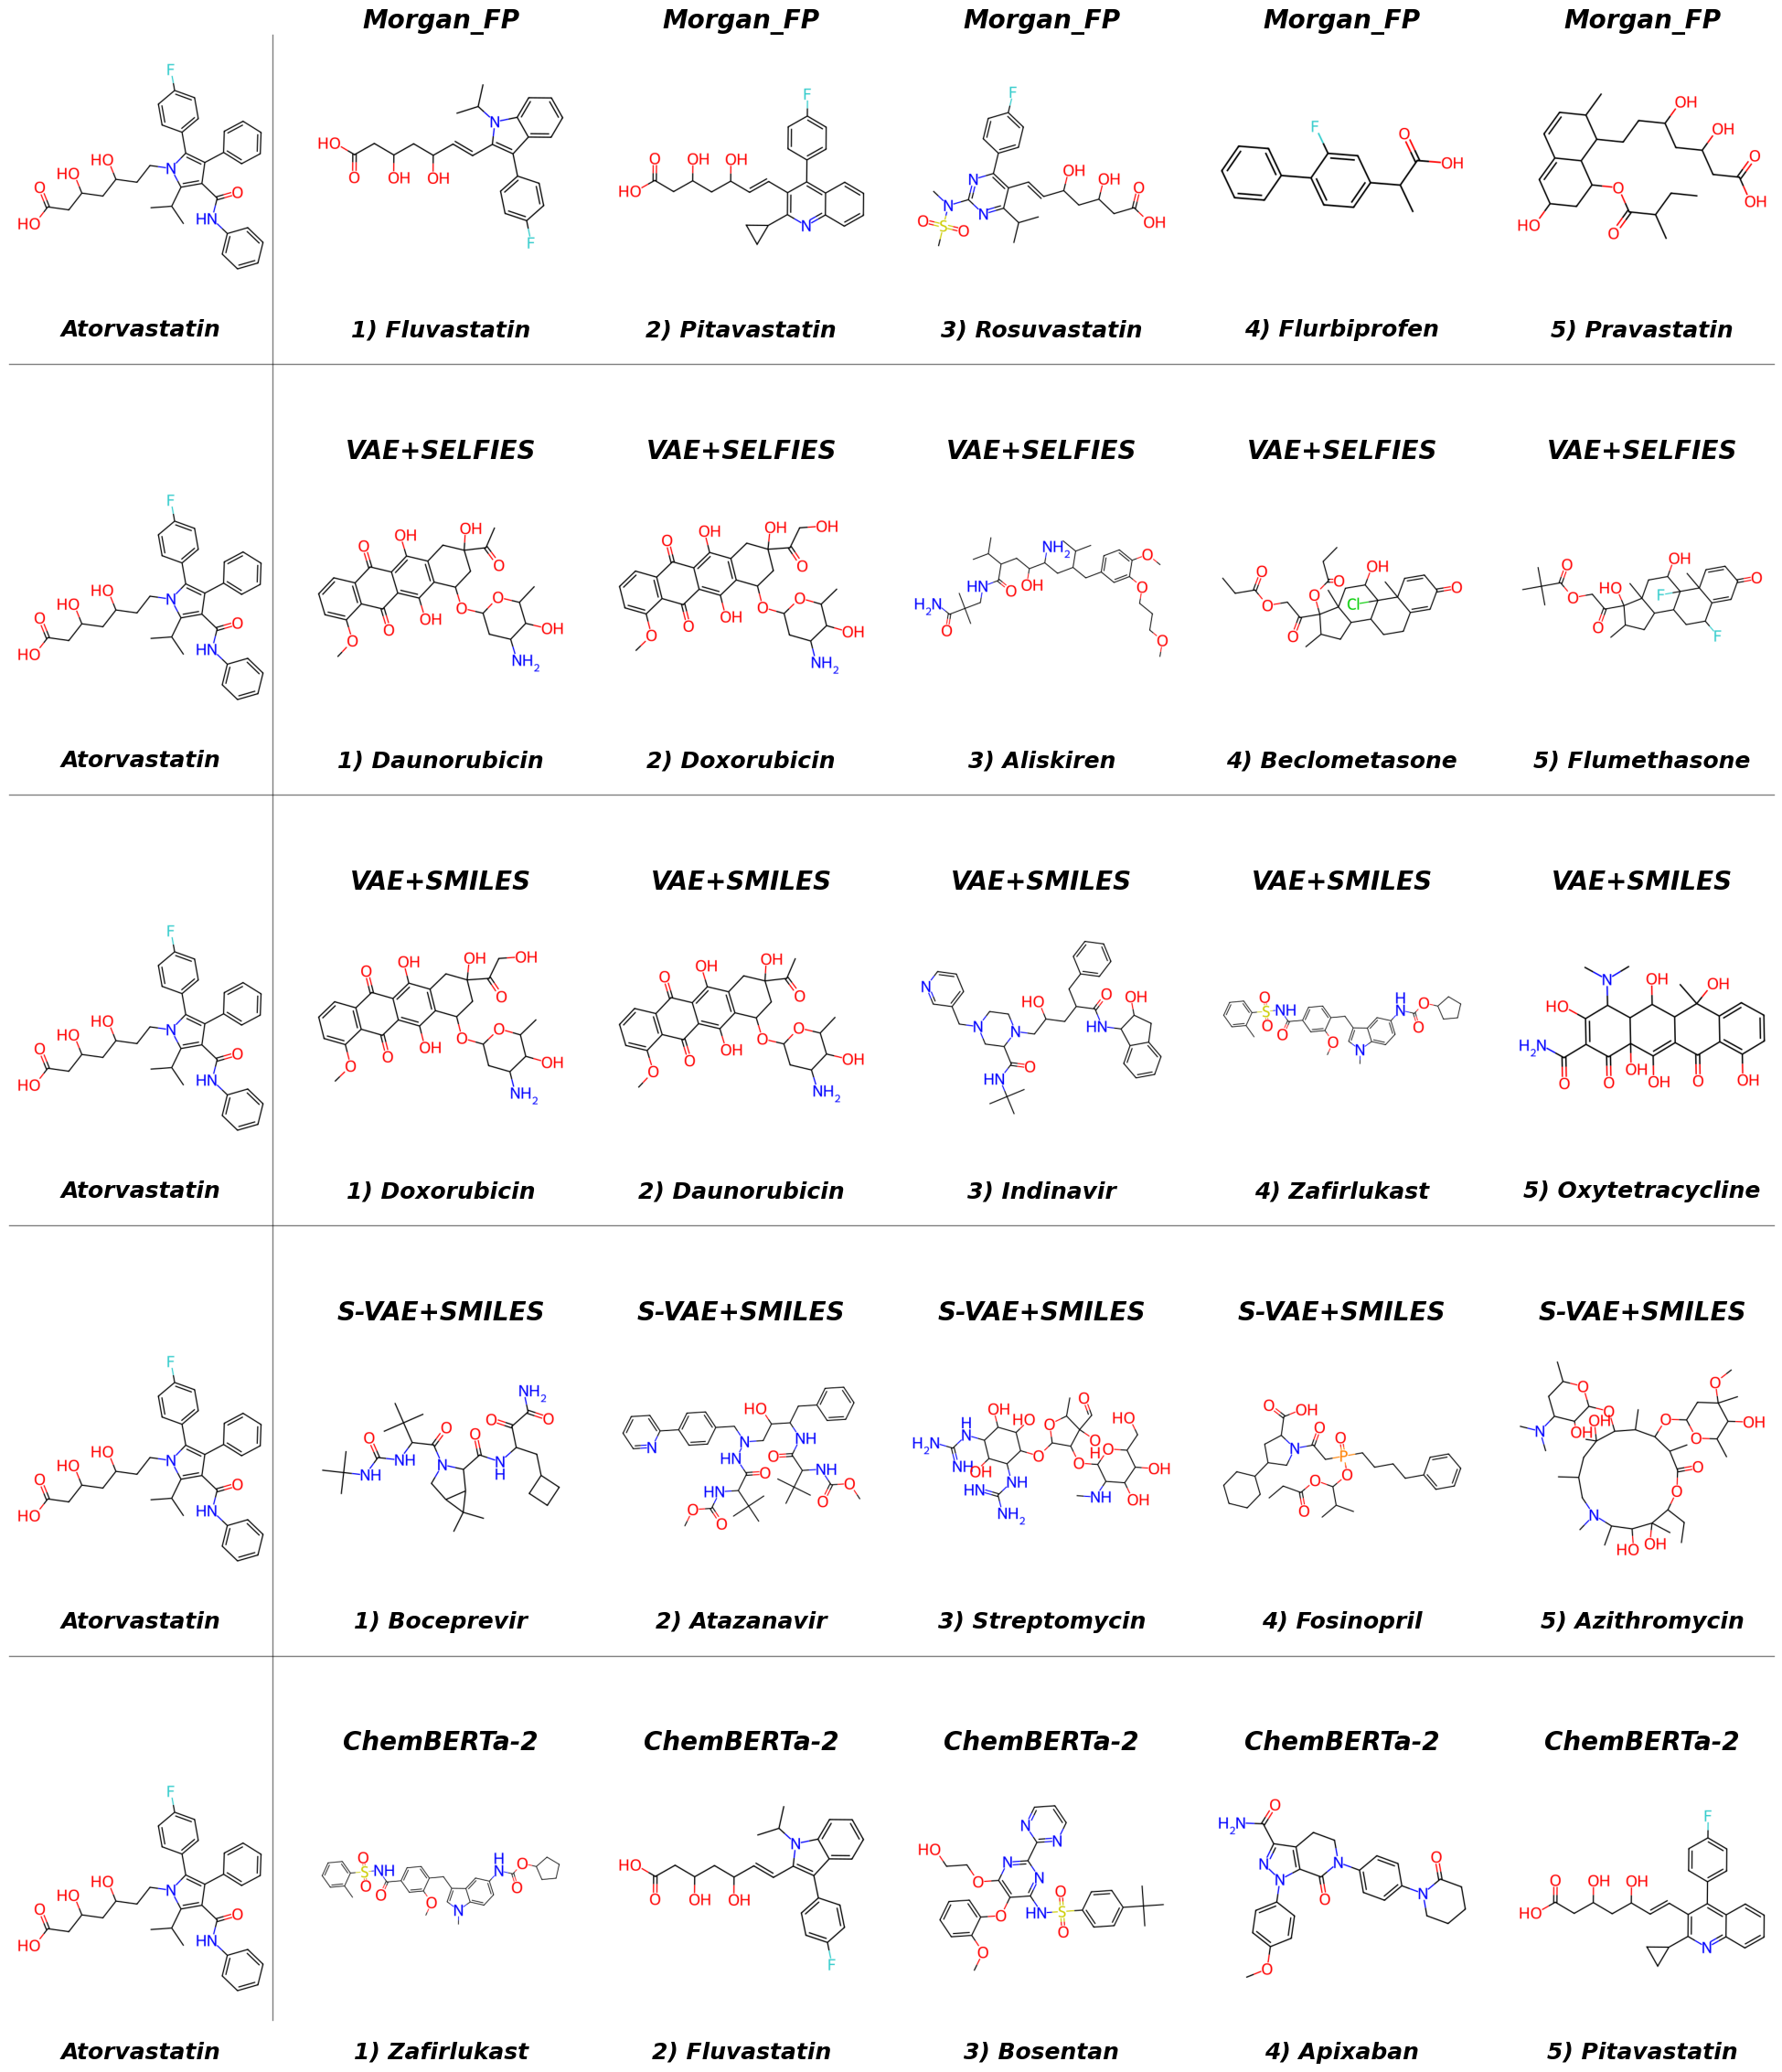

In [33]:
%matplotlib inline

def extract_first_part(text):
    # Splits by whitespace and joins the first two tokens
    parts = text.split()
    return " ".join(parts[:2])

drug = 'Clozapine'
drug = 'Atorvastatin'
idx = smiles_name.index(drug)
mul = (n_neigh+1)*5
n_smiles = slice(idx*mul, idx*mul+mul)
smiles = all_smiles_drug[n_smiles]
legends = all_smiles_name[n_smiles]
legends = [extract_first_part(x) for x in legends]
titles = all_smiles_title[n_smiles]

plot_smiles_grid(smiles_list=smiles, 
                 legends=legends, 
                 titles=titles, 
                 cols=(n_neigh+1), 
                 separate_first_column=True,
                 legendfontsize=18,
                 atom_font_size=30,
                #  figsize = (30, 30),
                 image_size=(500, 500)

                 )

In [35]:
%matplotlib inline

req_drugs = top_drugs#['Clozapine', 'Loxapine']
idx = [smiles_name.index(drug) for drug in req_drugs]


for i in idx:
    mul = (n_neigh+1)*5
    n_smiles = slice(i*mul, (i+1)*mul)
    smiles = all_smiles_drug[n_smiles]
    legends = all_smiles_name[n_smiles]
    legends = [extract_first_part(x) for x in legends]
    titles = all_smiles_title[n_smiles]

    plot_smiles_grid(smiles_list=smiles, 
                    legends=legends, 
                    titles=titles, 
                    cols=(n_neigh+1), 
                    separate_first_column=True,
                    savepath=f'/home/rkmvu/Codes/ICDCIT_submission/results/images/{legends[0]}.png',
                    legendfontsize=15,
                    atom_font_size=30,
                    # figsize = (30, 10),
                    image_size=(500, 500)
                    )

Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Metformin.png
Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Amoxicillin.png
Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Atorvastatin.png
Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Amlodipine.png
Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Acetaminophen.png
Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Imatinib.png
Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Clozapine.png
Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Ibuprofen.png
Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Azithromycin.png
Figure saved in: /home/rkmvu/Codes/ICDCIT_submission/results/images/Doxycycline.png
